In [ ]:
                                          # ------ COFFEE SHOP REVENUE ------ #

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('coffee_shop_revenue.csv')
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [5]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


In [6]:
print(df.isnull().sum())

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

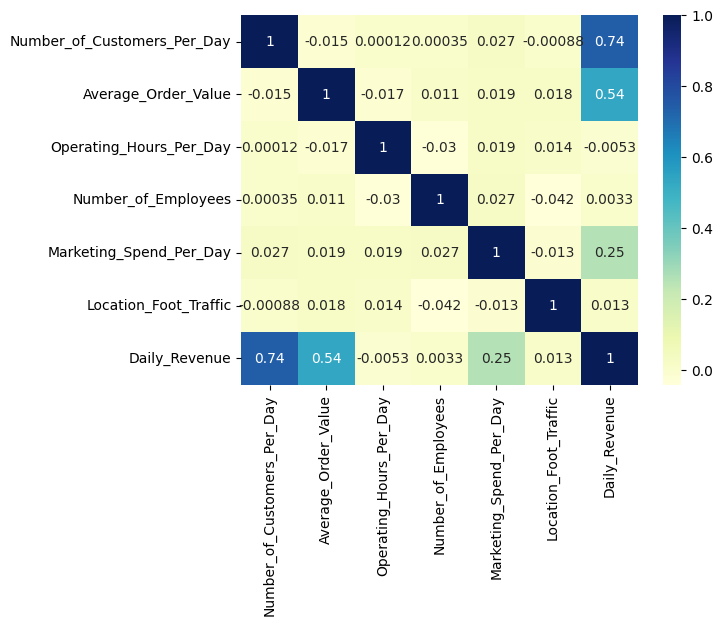

In [8]:
sns.heatmap(df.corr(),cmap='YlGnBu',annot=True)
plt.show()

In [10]:
X = df.drop('Daily_Revenue', axis=1)
y = df['Daily_Revenue']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=100)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1400, 6)
(600, 6)
(1400,)
(600,)


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Handle negative 'Daily_Revenue' values
df_cleaned = df[df['Daily_Revenue'] > 0].copy()

X = df_cleaned.drop('Daily_Revenue', axis=1)
y = df_cleaned['Daily_Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Original DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_cleaned.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Original DataFrame shape: (2000, 7)
Cleaned DataFrame shape: (1999, 7)
X_train shape: (1599, 6)
X_test shape: (400, 6)
y_train shape: (1599,)
y_test shape: (400,)


In [16]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [17]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred=model.predict(X_test)

In [19]:
y_pred

array([2655.79402733, 1626.17672117,  453.08928209, 2139.9014416 ,
       3391.63261504, 1268.91893161, 1824.53689314, 2078.7895526 ,
        875.7617094 , 3148.90421194,  575.12466954, 3699.60042255,
       1010.40281032, 2285.65096334, 2607.53334602, 2362.38873454,
        715.06936001, 2863.96018306, 1465.97388293,  735.86906303,
       3498.36719389, 2380.00564308, 3164.56673401, 2298.7450636 ,
       1573.14723529, 2223.71060031, 1656.45256397, 1614.67523303,
       2458.96055878, 2579.59675269, 3099.90368539, 2004.3383747 ,
        961.67745147, 2029.51303381, 1465.82846055, 2807.60573203,
       2028.27610499, 2260.24467776, 2185.58580055, 1086.06284316,
        854.73949041, 3418.4210505 ,  953.4950965 ,  332.07186653,
       1073.77531857,  862.1351669 , 1603.12189987, 2297.45387532,
       3344.02931459, 2927.22274146, 1745.40185461,  -61.89154712,
       3031.01821776, 3347.39702909, 3226.25551396, 3315.840745  ,
        782.37192513, 2092.54670492, 1665.15012511,  730.90724

In [20]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,r2_score
mean_absolute_error(y_test,y_pred)

0.8970451051753108

In [21]:
mean_absolute_percentage_error(y_test,y_pred)

0.1982599699135731

In [22]:
mean_squared_error(y_test,y_pred)

99601.1921324606

In [23]:
r2_score(y_test,y_pred)

0.8970451051753108

R-squared: 0.8970451051753108
Adjusted R-squared: 0.895473274719972


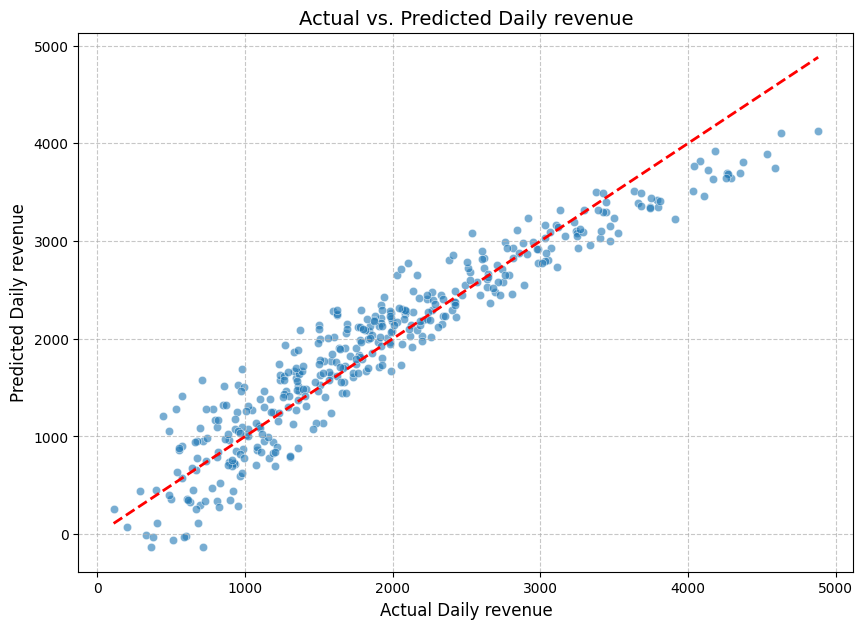

In [24]:
mean_squared_error(y_test,y_pred)
r_squared = r2_score(y_test, y_pred)
n = len(y_test)  
p = X_test.shape[1]  
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Actual Daily revenue', fontsize=12)
plt.ylabel('Predicted Daily revenue', fontsize=12)
plt.title('Actual vs. Predicted Daily revenue', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("Decision Tree Regression Model Performance:")
print(f"R-squared: {r2_dt:.4f}")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")

Decision Tree Regression Model Performance:
R-squared: 0.8753
Mean Absolute Error (MAE): 278.84
Mean Squared Error (MSE): 120627.37
Root Mean Squared Error (RMSE): 347.31


In [29]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regression Model Performance:")
print(f"R-squared: {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")

Random Forest Regression Model Performance:
R-squared: 0.9463
Mean Absolute Error (MAE): 182.93
Mean Squared Error (MSE): 51985.39
Root Mean Squared Error (RMSE): 228.00


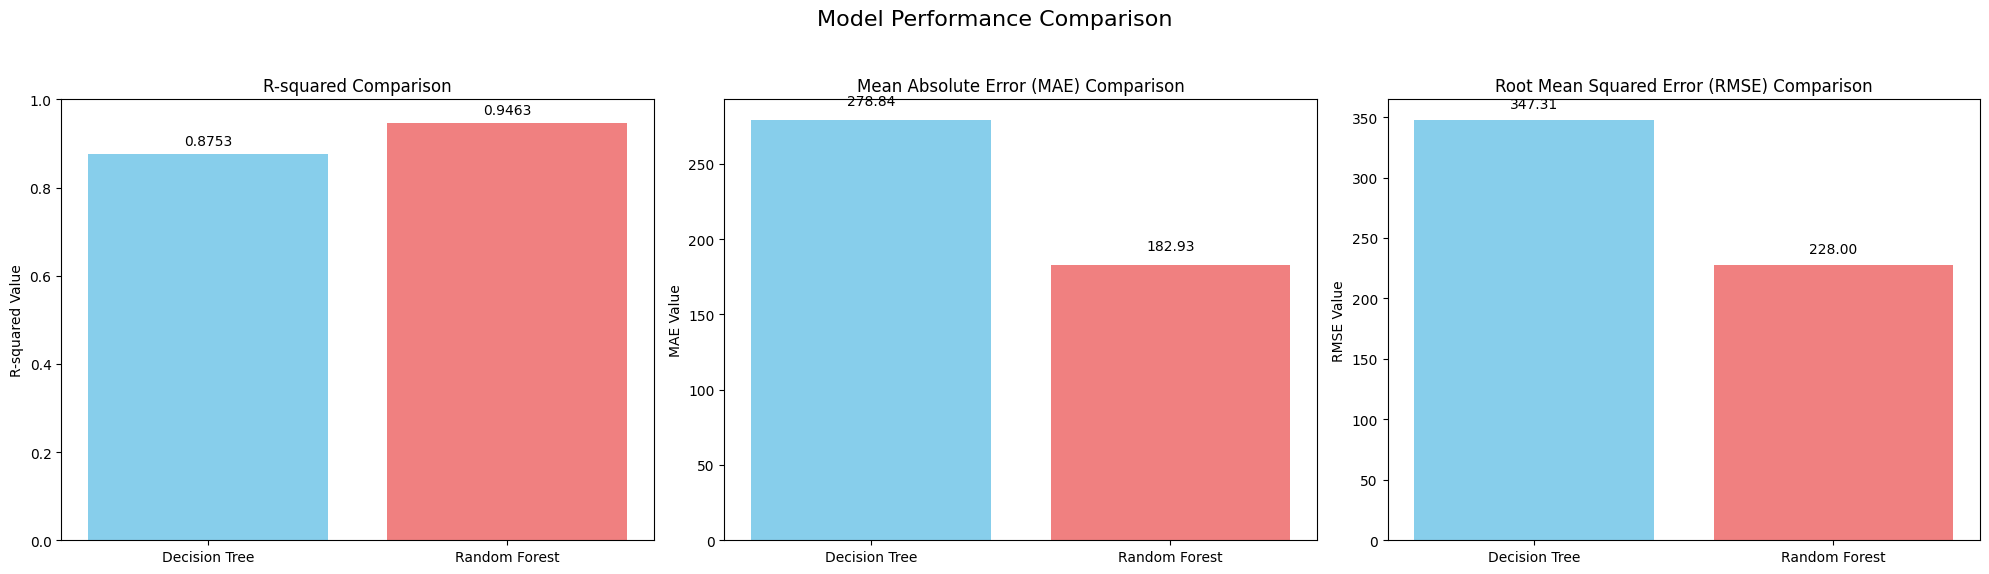

In [30]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest']

r2_scores = [r2_dt, r2_rf]
mae_scores = [mae_dt, mae_rf]
mse_scores = [mse_dt, mse_rf] 
rmse_scores = [rmse_dt, rmse_rf]

# Create a figure with subplots for better organization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Bar chart for R-squared
axes[0].bar(models, r2_scores, color=['skyblue', 'lightcoral'])
axes[0].set_title('R-squared Comparison')
axes[0].set_ylabel('R-squared Value')
axes[0].set_ylim(0, 1)
for i, score in enumerate(r2_scores):
    axes[0].text(i, score + 0.02, f'{score:.4f}', ha='center')

# Bar chart for MAE
axes[1].bar(models, mae_scores, color=['skyblue', 'lightcoral'])
axes[1].set_title('Mean Absolute Error (MAE) Comparison')
axes[1].set_ylabel('MAE Value')
for i, score in enumerate(mae_scores):
    axes[1].text(i, score + 10, f'{score:.2f}', ha='center')

# Bar chart for RMSE
axes[2].bar(models, rmse_scores, color=['skyblue', 'lightcoral'])
axes[2].set_title('Root Mean Squared Error (RMSE) Comparison')
axes[2].set_ylabel('RMSE Value')
for i, score in enumerate(rmse_scores):
    axes[2].text(i, score + 10, f'{score:.2f}', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()
